In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.tree import (
    DecisionTreeRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
data = fetch_california_housing()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["HousePrice"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X = df.drop(
    "HousePrice",
    axis=1
)

y = df["HousePrice"]

print("Features and Target Created")

Features and Target Created


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Test Split Done")

Train Test Split Done


In [7]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

train_pred = tree.predict(
    X_train
)

test_pred = tree.predict(
    X_test
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Training RMSE: 3.218325866275131e-16
Testing RMSE: 0.7030445773467542


In [8]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()

print(
    "Cross Validation RMSE:",
    cv_rmse
)

Cross Validation RMSE: 0.8957031908951016


In [9]:
param_grid = {

    "max_depth": [3, 5, 7, 10],

    "min_samples_split": [2, 5, 10]

}

grid = GridSearchCV(

    DecisionTreeRegressor(
        random_state=42
    ),

    param_grid,

    scoring="neg_root_mean_squared_error",

    cv=5

)

grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")

print(
    grid.best_params_
)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10}


In [10]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("RMSE:", rmse)

print("R2 Score:", r2)

RMSE: 0.6454300828015771
R2 Score: 0.6820992539714815


In [11]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

In [12]:
ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train,
    y_train
)

ridge_pred = ridge.predict(
    X_test
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

In [13]:
results = {

    "Model": [

        "Linear Regression",

        "Ridge Regression",

        "Tuned Decision Tree"

    ],

    "RMSE": [

        lr_rmse,

        ridge_rmse,

        rmse

    ],

    "R2 Score": [

        lr_r2,

        ridge_r2,

        r2

    ]

}

comparison_df = pd.DataFrame(
    results
)

comparison_df

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


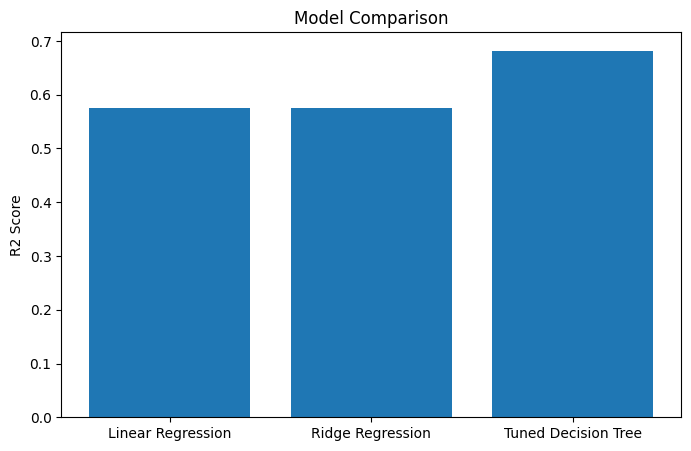

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R2 Score"]
)

plt.title(
    "Model Comparison"
)

plt.ylabel(
    "R2 Score"
)

plt.show()

In [15]:
best_model = comparison_df.loc[
    comparison_df["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

Best Model: Tuned Decision Tree
